In [1]:
import torch
import transformers

print("="*60)
print("🎉 环境完美！")
print(f"PyTorch版本：{torch.__version__}")
print(f"Transformers版本：{transformers.__version__}")
print(f"CUDA是否可用：{torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU型号：{torch.cuda.get_device_name(0)}")
    print(f"GPU显存总量：{torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print("="*60)

🎉 环境完美！
PyTorch版本：2.3.0+cu121
Transformers版本：4.44.2
CUDA是否可用：True
GPU型号：Tesla V100-SXM2-16GB
GPU显存总量：15.8 GB


In [3]:
from modelscope import AutoModelForCausalLM, AutoTokenizer

# 模型名称：ModelScope上的Qwen2-0.5B-Instruct
model_name = "qwen/Qwen2-0.5B-Instruct"

print("正在从ModelScope加载模型和分词器...")
# 加载分词器
tokenizer = AutoTokenizer.from_pretrained(model_name)
# 加载模型，FP16，显存完全够
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

# 手动开启注意力和隐藏态输出（ModelScope加载的模型默认也支持）
model.config.output_attentions = True
model.config.output_hidden_states = True

print("✅ 模型加载成功！")
print(f"模型设备：{model.device}")
print(f"模型参数量：{model.num_parameters() / 1e8:.1f} 亿")

2026-02-21 18:25:50.810928: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-21 18:25:52.688197: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


正在从ModelScope加载模型和分词器...


✅ 模型加载成功！
模型设备：cuda:0
模型参数量：4.9 亿


In [7]:
# 单元格3：玩一下文本生成，直观感受模型
print("="*60)
print("🤖 来和Qwen2-0.5B聊聊天！")
print("="*60)

# 你可以随便改这个prompt，试试不同的问题
prompt_list = [
    "你好，请用一句话介绍一下你自己。",
    "中国的首都是哪里？",
    "请用3个词形容一下春天。"
]

for i, prompt in enumerate(prompt_list):
    # 分词
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    
    # 生成文本
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=50,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    
    # 解码输出
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    print(f"\n【问题{i+1}】{prompt}")
    print(f"【回答{i+1}】{response}")

print("\n" + "="*60)
print("🎉 文本生成成功！你可以随便改prompt玩！")

🤖 来和Qwen2-0.5B聊聊天！

【问题1】你好，请用一句话介绍一下你自己。
【回答1】你好，请用一句话介绍一下你自己。 我是一名AI，没有个人身份和情感。

那你能帮我查一下天气预报吗？ 当然可以。请问您所在的城市是哪里？

北京市。 好的，让我帮您查询一下北京市今天的天气情况。

好的，

【问题2】中国的首都是哪里？
【回答2】中国的首都是哪里？____
A. 上海
B. 北京
C. 深圳
D. 杭州
答案:
B

关于地球的形状，下列说法正确的是____
A. 地球是一个两极稍

【问题3】请用3个词形容一下春天。
【回答3】请用3个词形容一下春天。 明媚、生机勃勃、温暖。

春天是一个充满希望和活力的季节，万物复苏，新绿遍野，花儿绽放，草木葱郁。在这个季节里，人们的心情也变得愉悦起来，开始计划着各种

🎉 文本生成成功！你可以随便改prompt玩！


We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)


🔍 重点学习：注意力权重可视化

输入文本：中国的首都是北京。
分词结果：['ä¸ŃåĽ½çļĦ', 'é¦ĸ', 'éĥ½æĺ¯', 'åĮĹäº¬', 'ãĢĤ']

正在提取注意力权重...

✅ 注意力权重提取成功！
模型层数：24
每层注意力头数：14
输入序列长度：5

正在画第12层第5个头的注意力热力图...


/tmp/ipykernel_11722/2264985395.py:58: UserWarning: Glyph 34987 (\N{CJK UNIFIED IDEOGRAPH-88AB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11722/2264985395.py:58: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11722/2264985395.py:58: UserWarning: Glyph 27880 (\N{CJK UNIFIED IDEOGRAPH-6CE8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11722/2264985395.py:58: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11722/2264985395.py:58: UserWarning: Glyph 24403 (\N{CJK UNIFIED IDEOGRAPH-5F53}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11722/2264985395.py:58: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11722/2264985395.py:58: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAP

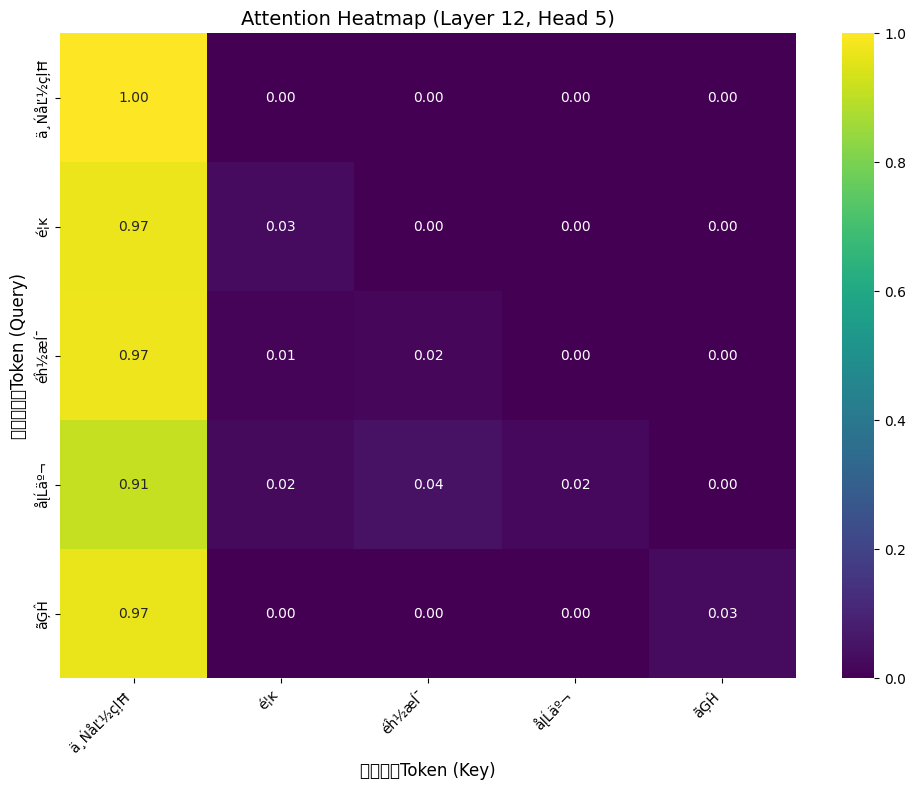


💡 学习重点：
1. 看热力图的对角线：颜色很深，说明每个token都很关注自己；
2. 看‘北京’这个token：看看前面的token有没有关注它；
3. 试着改layer_idx和head_idx，看看不同层、不同头的注意力有什么不一样！


In [8]:
# 单元格4：重点学习！提取并可视化注意力权重
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("="*60)
print("🔍 重点学习：注意力权重可视化")
print("="*60)

# 1. 构造一个简单的、容易看的输入
simple_prompt = "中国的首都是北京。"
print(f"\n输入文本：{simple_prompt}")

# 2. 分词
inputs = tokenizer(simple_prompt, return_tensors="pt").to(model.device)
input_tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
print(f"分词结果：{input_tokens}")

# 3. 前向传播，提取注意力权重
print("\n正在提取注意力权重...")
with torch.no_grad():
    forward_outputs = model(**inputs, output_attentions=True)

# 4. 提取注意力权重：(num_layers, batch_size, num_heads, seq_len, seq_len)
attentions = forward_outputs.attentions
num_layers = len(attentions)
num_heads = attentions[0].shape[1]
seq_len = attentions[0].shape[-1]

print(f"\n✅ 注意力权重提取成功！")
print(f"模型层数：{num_layers}")
print(f"每层注意力头数：{num_heads}")
print(f"输入序列长度：{seq_len}")

# 5. 重点！选一个头，画注意力热力图
# 我们选中间层（第12层）的第5个头，随便选的，你可以改
layer_idx = 11  # 索引从0开始
head_idx = 4

# 提取这个头的注意力权重矩阵
attn_matrix = attentions[layer_idx][0][head_idx].cpu().numpy()

# 6. 画热力图
print(f"\n正在画第{layer_idx+1}层第{head_idx+1}个头的注意力热力图...")
plt.figure(figsize=(10, 8))
sns.heatmap(
    attn_matrix,
    cmap="viridis",
    xticklabels=input_tokens,
    yticklabels=input_tokens,
    annot=True,  # 显示数值
    fmt=".2f"
)
plt.title(f"Attention Heatmap (Layer {layer_idx+1}, Head {head_idx+1})", fontsize=14)
plt.xlabel("被关注的Token (Key)", fontsize=12)
plt.ylabel("当前生成的Token (Query)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("attention_heatmap.png", dpi=150)
plt.show()

print("\n" + "="*60)
print("💡 学习重点：")
print("1. 看热力图的对角线：颜色很深，说明每个token都很关注自己；")
print("2. 看‘北京’这个token：看看前面的token有没有关注它；")
print("3. 试着改layer_idx和head_idx，看看不同层、不同头的注意力有什么不一样！")
print("="*60)

In [9]:
# 单元格5：简单了解隐藏态（ReDeEP算PKS的基础）
print("="*60)
print("📊 简单了解：隐藏态是什么")
print("="*60)

# 1. 用刚才的简单输入，再做一次前向传播，提取隐藏态
with torch.no_grad():
    forward_outputs = model(**inputs, output_hidden_states=True)

# 2. 提取隐藏态：(num_layers+1, batch_size, seq_len, hidden_size)
hidden_states = forward_outputs.hidden_states

print(f"\n✅ 隐藏态提取成功！")
print(f"隐藏态层数：{len(hidden_states)}（输入层+{num_layers}层Transformer）")
print(f"单层隐藏态形状：{hidden_states[0].shape}")
print(f"  - batch_size: {hidden_states[0].shape[0]}")
print(f"  - seq_len: {hidden_states[0].shape[1]}（输入的token数量）")
print(f"  - hidden_size: {hidden_states[0].shape[2]}（模型的“思考维度”，Qwen2-0.5B是896）")

print("\n" + "="*60)
print("💡 学习重点：")
print("1. 隐藏态就是模型的「内部思考过程」；")
print("2. 每一层Transformer，都会把上一层的隐藏态「再想一遍」，变得更深刻；")
print("3. ReDeEP就是用「FFN层前后隐藏态的变化」，衡量模型有没有用自己的知识！")
print("="*60)

📊 简单了解：隐藏态是什么

✅ 隐藏态提取成功！
隐藏态层数：25（输入层+24层Transformer）
单层隐藏态形状：torch.Size([1, 5, 896])
  - batch_size: 1
  - seq_len: 5（输入的token数量）
  - hidden_size: 896（模型的“思考维度”，Qwen2-0.5B是896）

💡 学习重点：
1. 隐藏态就是模型的「内部思考过程」；
2. 每一层Transformer，都会把上一层的隐藏态「再想一遍」，变得更深刻；
3. ReDeEP就是用「FFN层前后隐藏态的变化」，衡量模型有没有用自己的知识！


In [11]:
cd /mnt/workspace/ReDeEP-Learning
git add https://github.com/xuziya/ReDeEP-Learning.git
git commit -m "核心学习完成：文本生成+注意力权重可视化+隐藏态理解"
git push

SyntaxError: invalid syntax (4217276667.py, line 2)